# Fourier-space based turbulent field generation

## 1. Isotropic Kolmogorov turbulence generation

1. Define the spatial cube

2. Calculate associated Fourier wavelength cube

3. Generate magnetic field spectrum in Fourier space

4. Perform an inverse Fourier transform

### 1.1. Define spatial cube

In [627]:
import numpy as np

In [628]:
n = (256, 256, 256)  # grid shape

L_x, L_y, L_z = 50, 50, 50
xyz_min = (-L_x, -L_y, -L_z)  # [pc], minimal values
xyz_max = (+L_x, +L_y, +L_z)  # [pc], maximal values

xyz = np.array([np.linspace(xyz_min[i], xyz_max[i], n[i], endpoint=False) for i in range(len(n))])

r_grid = np.stack(np.meshgrid(*xyz, indexing='ij'))  # 3D coordinate grid
print(f"Coordinate grid shape: {r_grid.shape}")
print(f"In close: [[x], [y], [z]]\n"
      f"{r_grid[:, 10:12, 20:22, 0:2]}")

Coordinate grid shape: (3, 256, 256, 256)
In close: [[x], [y], [z]]
[[[[-46.09375  -46.09375 ]
   [-46.09375  -46.09375 ]]

  [[-45.703125 -45.703125]
   [-45.703125 -45.703125]]]


 [[[-42.1875   -42.1875  ]
   [-41.796875 -41.796875]]

  [[-42.1875   -42.1875  ]
   [-41.796875 -41.796875]]]


 [[[-50.       -49.609375]
   [-50.       -49.609375]]

  [[-50.       -49.609375]
   [-50.       -49.609375]]]]


### 1.2. Calculate associated Fourier wavelength cube

To save memory, we benefit from the fact that for Fourier images of real fieids,
$ \mathbf{\tilde{B}}(-\mathbf{k}) = \mathbf{\tilde{B}^*}(\mathbf{k}) $.

This allows for Fourier space reduction along one of the axes. We choose the $z$-axis for this purpose.

In [629]:
from scipy.fft import fftfreq, rfftfreq

In [630]:
Nx, Ny, Nz = r_grid.shape[1:]
dx, dy, dz = xyz[:, 1] - xyz[:, 0]

k_x = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
k_y = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)
k_z = 2 * np.pi * np.fft.rfftfreq(Nz, d=dz)

k_grid = np.stack(
    np.meshgrid(k_x, k_y, k_z, indexing='ij')
)

In [631]:
print(f"Wavelength grid shape: {k_grid.shape}")
print(f"In close: [[k_x], [k_y], [k_z]]\n"
      f"{k_grid[:, 10:12, 20:22, 0:2]}")

Wavelength grid shape: (3, 256, 256, 129)
In close: [[k_x], [k_y], [k_z]]
[[[[0.62831853 0.62831853]
   [0.62831853 0.62831853]]

  [[0.69115038 0.69115038]
   [0.69115038 0.69115038]]]


 [[[1.25663706 1.25663706]
   [1.31946891 1.31946891]]

  [[1.25663706 1.25663706]
   [1.31946891 1.31946891]]]


 [[[0.         0.06283185]
   [0.         0.06283185]]

  [[0.         0.06283185]
   [0.         0.06283185]]]]


### 1.3A. Magnetic field power spectrum

#### Definition

Consider magnetic field $\mathbf{B}(\mathbf{r})$.

Do a Fourier transform $\displaystyle\mathbf{\tilde{B}}(\mathbf{k}) = \dfrac{1}{(2\pi)^{3/2}V} \int_V d\mathbf{r}\,\mathbf{B}(\mathbf{r}) e^{-i\mathbf{kr}}$.

To obtain *power spectrum*, we integrate magnetic field power over a surface of given $k = |\mathbf{k}|$:
$$E(k) = \oint_{|\mathbf{k}| = k} |\mathbf{\tilde{B}}(\mathbf{k})|^2 dS_k$$

#### The case of isotropic Kolmogorov turbulence

For *isotropic turbulence*, this integral is analytical! We define $P_B(k) = |\mathbf{\tilde{B}}(\mathbf{k})|^2$ and obtain
$$ E(k) = 4\pi k^2 P_B(k) $$

Kolmogorov magnetic field power spectrum: $ E(k) \propto k^{-5/3} $, which gives $P_B(k) \propto k^{-11/3}$.

#### How to generate this MF spectrum?

To generate the desired magnetic field spectrum, we

*   Create a white noise field $\mathbf{\tilde{b}}(\mathbf{k})$ in Fourier space

    *Note that for a real magnetic field, $\mathbf{\tilde{b}}(-\mathbf{k}) = \mathbf{\tilde{b}}(\mathbf{k})^*$*

*   Reweight each of the Fourier modes by $\sqrt{P_B(k)}$: $\mathbf{\tilde{b}'}(\mathbf{k}) = \mathbf{\tilde{b}}(\mathbf{k})\sqrt{P_B(k)}$

*   Apply the orthogonal projector $\Pi_{ij}(\mathbf{k}) = \delta_{ij} - n_i n_j$, where $n = \mathbf{k}/k$ to ensure $\nabla\cdot \mathbf{B} = 0$:
    $\mathbf{\tilde{B}}(\mathbf{k}) = \mathbf{\tilde{b}'} - \mathbf{n}(\mathbf{n\cdot \tilde{b'}}) $

### 1.3B. Generation of magnetic field

#### White noise field

*Comment.* The variance does not play a role in this case!

If we generate $\tilde{b}_j(\mathbf{k}) = \dfrac{1}{\sqrt{2}}(X + iY),$ where $X,Y\sim\mathcal{N}(0, 1)$, we ensure that $\langle\mathbf{\tilde{b}}^2(\mathbf{k})\rangle = 1$.

If we choose variance $\sigma_b$, we obtain $\langle|\mathbf{\tilde{b}}(\mathbf{k})|^2\rangle = \sigma_b^2$, which in the end influences only the power spectrum normalization: $P_B \propto \sigma_b^2$.

We proceed with the **standard normal distribution**.

In [632]:
from scipy.stats import norm

In [633]:
rng = np.random.default_rng()

b_re = rng.normal(size=k_grid.shape)  # real part
b_im = rng.normal(size=k_grid.shape)  # imaginary part

b_field = 1/np.sqrt(2) * (b_re + 1j * b_im)

#### Fourier mode reweighting

$\mathbf{\tilde{b}'}(\mathbf{k}) = \mathbf{\tilde{b}}(\mathbf{k})\sqrt{P_B(k)}$

*Comment.* The $\mathbf{k}=\vec{0}$ mode has to be treated separately! Its power is by definition taken to be $P(\vec{0}) = 0$.

In [634]:
k_norm_grid = np.sqrt(np.sum(k_grid**2, axis=0))  # calculate k-vector norms

power_grid = np.zeros_like(k_norm_grid)  # set the power grid
mask = k_norm_grid > 0  # exclude the 0-mode
power_grid[mask] = k_norm_grid[mask]**(-11/3)  # Kolmogorov spectrum

b_prime_field = b_field * np.sqrt(power_grid[None, ...])

#### Orthogonal projection

$\mathbf{\tilde{B}}(\mathbf{k}) = \mathbf{\tilde{b}'} - \mathbf{n}(\mathbf{n\cdot \tilde{b'}}) $

*Comment.* Again $\mathbf{k}=\vec{0}$ mode has to be treated separately. For it $\mathbf{n} = \vec{0}.$

In [635]:
n_grid = np.zeros_like(k_grid)
n_grid[:, mask] = k_grid[:, mask] / k_norm_grid[None, mask]

n_dot_b = np.sum(n_grid * b_prime_field, axis=0)  # scalar product

B_k_field = b_prime_field - n_grid * n_dot_b[None, ...]
B_k_field[:, 0, 0, 0] = np.array([0, 0, 0])

### 1.4. Inverse Fourier transform

The final step in magnetic field generation is inverse Fourier transform to the coordinate space.

As previously we used full $k_x$ and $k_y$ axes, but contracted $k_z$ to constrain real fields, we use `irfftn`

In [636]:
from scipy.fft import irfftn

In [637]:
B_field = np.zeros_like(r_grid)
for i in range(3):
    B_field[i] = irfftn(B_k_field[i], s=r_grid.shape[1:], norm='backward', workers=10)
    
B_norm = np.average(B_field**2, axis=(1,2,3))
print(B_norm)

B_field /= np.sqrt(3 * B_norm)[:, None, None, None]

[1.37915851e-09 1.26220510e-09 1.12735308e-09]


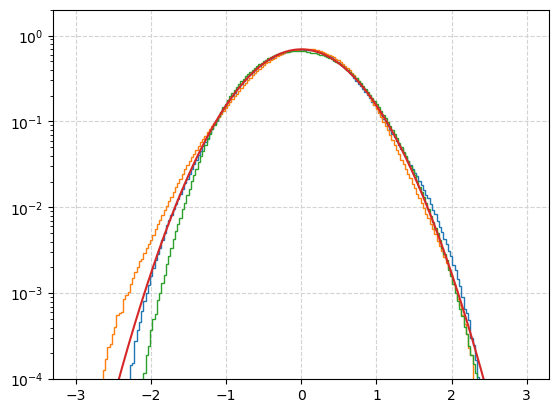

In [638]:
import matplotlib.pyplot as plt
from scipy.stats import norm

vals = np.linspace(-3, 3, 1000)
plt.hist(B_field[0].ravel(), bins=200, range=[-3, 3], histtype='step', density=True)
plt.hist(B_field[1].ravel(), bins=200, range=[-3, 3], histtype='step', density=True)
plt.hist(B_field[2].ravel(), bins=200, range=[-3, 3], histtype='step', density=True)

plt.plot(vals, norm(loc=0, scale=1/np.sqrt(3)).pdf(vals))

plt.ylim(1e-4, 2)
plt.yscale('log')

plt.grid(linestyle='dashed', color='lightgray')
plt.show()

### 1.5. Tests

#### A. Fourier space transversality check

In [522]:
from scipy.fft import fftn, ifftn

In [523]:
# check the transversality
div_k = np.sum(1j * k_grid * B_k_field, axis=0)
test_value = np.abs(div_k).max()
print(f"Maximal value of divergence: {test_value:.4g}")

if test_value < 1e-10:
    print("TEST PASSED")
else:
    print("! ATTENTION ! TEST FAILURE...")

Maximal value of divergence: 2.581e-15
TEST PASSED


#### B. Full FFT divergence-free check

In [524]:
# real space divergence check
kx = 2 * np.pi * fftfreq(Nx, d=dx)
ky = 2 * np.pi * fftfreq(Ny, d=dy)
kz = 2 * np.pi * fftfreq(Nz, d=dz)

k_grid_full = np.stack(
    np.meshgrid(kx, ky, kz, indexing='ij')
    )

B_k = np.zeros_like(k_grid_full, dtype=complex)
for i in range(3):
    B_k[i] = fftn(B_field[i])

div_k = 1j * np.sum(k_grid_full * B_k, axis=0)
div = ifftn(div_k, s=r_grid.shape[1:])
test_value = np.max(np.abs(div))

print(f"Maximal value of divergence: {test_value:.4g}")
if test_value < 1e-3:
    print("TEST PASSED")
else:
    print("! ATTENTION ! TEST FAILURE...")

Maximal value of divergence: 0.1748
! ATTENTION ! TEST FAILURE...


#### C. Power-spectrum slope check

In [525]:
from scipy.stats import binned_statistic

In [526]:
dk = min(
    np.abs(kx[1]-kx[0]),
    np.abs(ky[1]-ky[0]),
    np.abs(kz[1]-kz[0]),
)

bins = np.arange(0, kx.max() + dk, dk)

In [527]:
# obtain spectral energy density of the magnetic field in Fourier space
Bk2 = (np.sum(np.abs(B_k)**2, axis=0))  # sum of the squares of the Fourier transformed components
k = np.sqrt(np.sum(k_grid_full**2, axis=0))  # calculate the magnitude of the wavevector

k_flat = k.ravel()
Bk2_flat = Bk2.ravel()

In [528]:
from scipy.stats import binned_statistic

power, edges, _ = binned_statistic(
    k_flat,
    Bk2_flat,
    statistic="sum",
    bins=bins,
)

k_centers = 0.5 * (edges[:-1] + edges[1:])

In [529]:
import matplotlib.pyplot as plt

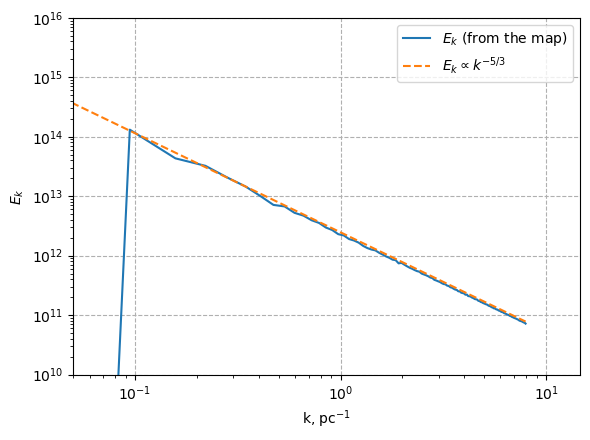

In [646]:
plt.figure(figsize=(6, 4.5))
plt.loglog(k_centers, power, label=r'$E_k$ (from the map)')
plt.loglog(k_centers, power[5] * (k_centers / k_centers[5])**(-5/3), linestyle='dashed', label=r'$E_k\propto k^{-5/3}$')

plt.xlim(k.min() + 5e-2, k.max() * 1.05)
plt.xlabel(r'k, $\mathrm{pc}^{-1}$')

plt.ylim(1e10, 1e16)
plt.ylabel(r'$E_k$')

plt.legend(loc=1)

plt.grid(linestyle='dashed')

plt.tight_layout()
plt.show()

#### D. Isotropy check

In [531]:
print(k_grid_full.shape)
print(k.shape)

(3, 256, 256, 256)
(256, 256, 256)


To check isotropy, we investigate distributions in $\mu = \cos\theta_z = k_z/k$ and $\nu = \cos\theta_x = k_x/k$.

However, if we simply bin the array in the angles, we will be dominated by large $k$ as $P(k)\propto k^{-11/3}$.

So, we first bin in $k$, normalize the distribution and then bin it in $\mu$ or $\nu$.

In [532]:
mu, nu = np.zeros_like(k), np.zeros_like(k)

In [533]:
# Flatten arrays
k_flat = k.ravel()
mu_flat = mu.ravel()
Bk2_flat = Bk2.ravel()

# Remove k = 0 mode
mask = k_flat > 0

In [534]:
mask.shape

(16777216,)

In [535]:
# Remove k = 0 mode
mask = (k > 0.1) & (k < 5)
k_mask = k[mask]
mu_mask = k_grid_full[0][mask] / k_mask
Bk2_mask = Bk2[mask]

# flatten the arrays
k_flat = k_mask.ravel()
mu_flat = mu_mask.ravel()
Bk2_flat = Bk2_mask.ravel()

In [536]:
# ----- Shell-average spectrum -----
n_k_bins = 20
k_bins = np.geomspace(k_flat.min(), k_flat.max(), n_k_bins + 1)

shell_mean, _, shell_index = binned_statistic(
    k_flat,
    Bk2_flat,
    statistic="mean",
    bins=k_bins,
)

shell_mean

array([1.98024046e+12, 6.90036919e+11, 2.67532424e+11, 2.03258051e+11,
       1.16350856e+11, 5.11196222e+10, 2.44751642e+10, 1.16990576e+10,
       6.18091642e+09, 3.13851521e+09, 1.50761241e+09, 7.50376300e+08,
       3.70930243e+08, 1.83725417e+08, 9.13588481e+07, 4.56085576e+07,
       2.27178882e+07, 1.12322286e+07, 5.58425912e+06, 2.76796304e+06])

In [537]:
# Normalize each Fourier mode by its shell average
Bk2_norm = Bk2_flat / shell_mean[shell_index - 1]

# ----- Angular anisotropy -----
n_mu_bins = 100
mu_bins = np.linspace(-1, 1, n_mu_bins)

anisotropy, mu_edges, _ = binned_statistic(
    mu_flat,
    Bk2_norm,
    statistic="mean",
    bins=mu_bins,
)

mu_centers = 0.5 * (mu_edges[:-1] + mu_edges[1:])

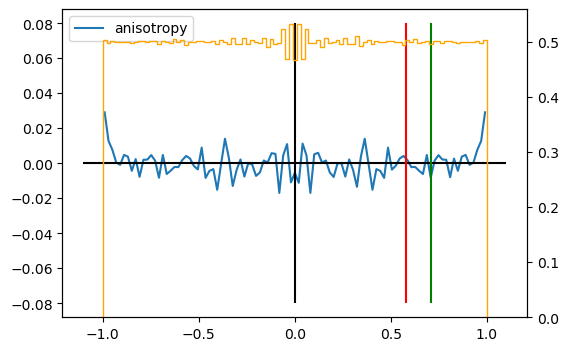

In [538]:
plt.figure(figsize=(6, 4))

ax = plt.subplot(111)
ax.plot(mu_centers, 1 - anisotropy, label='anisotropy')

ax2 = ax.twinx()
ax2.hist(mu_flat, bins=mu_bins, histtype='step', color='orange', density=True, label=r'$\mu$ distribution')

ax.hlines([0], -1.1, 1.1, color='black')
ax.vlines([0, 1/np.sqrt(3), 1/np.sqrt(2)], -0.08, 0.08, colors=['black', 'r', 'g'])

ax.legend(loc=2)

plt.show()

**Verdict:** The distribution is isotropic

#### E. Zero mean

In [539]:
np.mean(B_field)

np.float64(-2.2000269083351693e-17)

#### F. Correlation function

#### G. Parseval identity